In [26]:
from IPython.display import Image, display
from typing import Any
from typing_extensions import TypedDict,Annotated
import operator

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    state: Annotated[list,operator.add]

In [27]:
import threading
import time
def create_node(data:str):

   def node(state: State) -> State:
        time.sleep(2)
        print(f" inside node_{data} adding {data} in {threading.current_thread().name}")
        return {"state":  [data]}

   return node  


node_a = create_node("a")
node_b = create_node("b")
node_c = create_node("c")
node_d = create_node("d")
node_e = create_node("e")

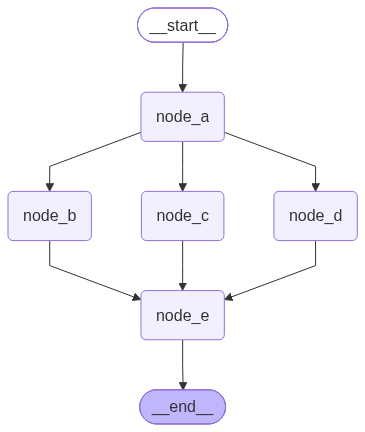

In [28]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)
workflow.add_node("node_a", node_a)
workflow.add_node("node_b", node_b)
workflow.add_node("node_c", node_c)
workflow.add_node("node_d", node_d)
workflow.add_node("node_e", node_e)

workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_a", "node_c")
workflow.add_edge("node_a", "node_d")

workflow.add_edge("node_b", "node_e")
workflow.add_edge("node_c", "node_e")
workflow.add_edge("node_d", "node_e")

workflow.add_edge("node_e", END)

graph =workflow.compile()
graph

In [29]:
graph.invoke({"state": []})

 inside node_a adding a in MainThread
 inside node_b adding b in ThreadPoolExecutor-5_0
 inside node_d adding d in ThreadPoolExecutor-5_2
 inside node_c adding c in ThreadPoolExecutor-5_1
 inside node_e adding e in MainThread


{'state': ['a', 'b', 'c', 'd', 'e']}

In [30]:
class State(TypedDict):
    order_id: str
    answer: str
    context: Annotated[list, operator.add]

In [31]:
import time
from langchain_core.messages import HumanMessage, SystemMessage

ORDERS = {
    "A1001": "Customer: Priya Shah. Item: TrailBlazer 30L backpack. Amount: Rs 4299. Payment: paid.",
    "A1002": "Customer: Arjun Mehta. Item: Noise-cancelling headphones. Amount: Rs 7999. Payment: paid.",
}

SHIPMENTS = {
    "A1001": "Carrier: BlueDart. Status: in transit. Last scan: Mumbai hub. ETA: 26 Sep 2026.",
    "A1002": "Carrier: Delhivery. Status: delivered. Delivered on: 20 Sep 2026. Signed by: reception.",
}


In [32]:


def lookup_order(state):
    """Read the order row. The sleep stands in for a slow database call."""
    order_id = state["order_id"]
    print(f"[{time.strftime('%H:%M:%S')}] lookup_order started for {order_id} in thread {threading.current_thread().name}")
    time.sleep(2)
    record = ORDERS.get(order_id, f"No order found for {order_id}.")
    print(f"[{time.strftime('%H:%M:%S')}] lookup_order finished for {order_id} in thread {threading.current_thread().name}")
    
    
    
    return {"context": [f"Order record: {record}"]}

In [33]:
def lookup_shipping(state):
    """Read the shipment row. Runs at the same time as lookup_order."""
    order_id = state["order_id"]
    print(f"[{time.strftime('%H:%M:%S')}] lookup_shipping started for {order_id} in thread {threading.current_thread().name}")
    time.sleep(2)
    record = SHIPMENTS.get(order_id, f"No shipment found for {order_id}.")
    print(f"[{time.strftime('%H:%M:%S')}] lookup_shipping finished for {order_id} in thread {threading.current_thread().name}")
    return {"context": [f"Shipping record: {record}"]}

In [34]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def generate_answer(state):
    """Write a customer update after both lookups have finished."""
    context = "\n\n".join(state["context"])
    order_id = state["order_id"]
    answer_instructions = (
        f"Write a short customer-support update for order {order_id}. "
        f"Use only this context:\n{context}"
    )
    answer = llm.invoke(
        [SystemMessage(content=answer_instructions)]
        + [HumanMessage(content="Write the update.")]
    )
    return {"answer": answer.content}

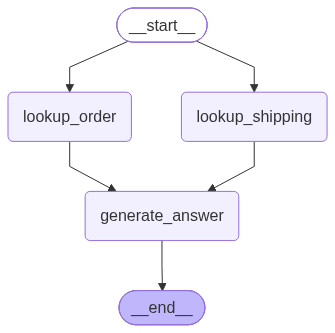

In [35]:
workflow = StateGraph(State)
workflow.add_node("lookup_order", lookup_order)
workflow.add_node("lookup_shipping", lookup_shipping)
workflow.add_node("generate_answer", generate_answer)

workflow.add_edge(START, "lookup_order")
workflow.add_edge(START, "lookup_shipping")
workflow.add_edge("lookup_order", "generate_answer")
workflow.add_edge("lookup_shipping", "generate_answer")
workflow.add_edge("generate_answer", END)

graph=workflow.compile()
graph

In [38]:
result=graph.invoke({"order_id": "A1001"})
result

[13:11:48] lookup_order started for A1001 in thread ThreadPoolExecutor-7_0
[13:11:48] lookup_shipping started for A1001 in thread ThreadPoolExecutor-7_1
[13:11:50] lookup_order finished for A1001 in thread ThreadPoolExecutor-7_0
[13:11:50] lookup_shipping finished for A1001 in thread ThreadPoolExecutor-7_1


{'order_id': 'A1001',
 'answer': 'Dear Priya Shah,\n\nThank you for your order A1001 for the TrailBlazer 30L backpack. We wanted to provide you with an update on your shipment.\n\nYour order is currently in transit with BlueDart. The last scan was recorded at the Mumbai hub, and the estimated time of arrival is set for September 26, 2026.\n\nWe appreciate your patience and will keep you informed of any further updates. If you have any questions or need assistance, please feel free to reach out.\n\nBest regards,  \nCustomer Support Team',
 'context': ['Order record: Customer: Priya Shah. Item: TrailBlazer 30L backpack. Amount: Rs 4299. Payment: paid.',
  'Shipping record: Carrier: BlueDart. Status: in transit. Last scan: Mumbai hub. ETA: 26 Sep 2026.']}

In [39]:
from IPython.display import Image, display,Markdown



Markdown(result['answer'])

Dear Priya Shah,

Thank you for your order A1001 for the TrailBlazer 30L backpack. We wanted to provide you with an update on your shipment.

Your order is currently in transit with BlueDart. The last scan was recorded at the Mumbai hub, and the estimated time of arrival is set for September 26, 2026.

We appreciate your patience and will keep you informed of any further updates. If you have any questions or need assistance, please feel free to reach out.

Best regards,  
Customer Support Team